In [12]:
#packages
import requests
import pandas as pd
import json
from glob import glob
from pathlib import Path
import csv
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import plotly.express as px

import geopandas as gpd
import seaborn as sns

In [2]:
#Note this is data with hurricane helene outages removed
outage_events = pd.read_csv('data_processed/PCA_data/outage_events.csv')

outage_events.dtypes

outage_identifer           int64
device_lat               float64
device_lon               float64
block_fips               float64
convex_hull               object
jurisdiction              object
origin                    object
state                     object
county                    object
affected                   int64
cause                     object
outage_start_estimate     object
outage_end_estimate       object
fix_duration_estimate     object
outage_restored           object
fix_duration_hours       float64
TRACT                      int64
overlaps_helene             bool
customer_minutes_out     float64
month                      int64
is_summer                   bool
is_winter                   bool
nearest_station           object
start_date                object
end_date                  object
outage_dates              object
dtype: object

In [6]:
basic_stats = outage_events[[
    "fix_duration_hours",
    "customer_minutes_out",
    "affected"
]].describe().T

basic_stats

,count,mean,std,min,25%,50%,75%,max
fix_duration_hours,776258.0,3.385793,8.393151,0.090556,0.482222,1.497222,3.168889,6.999989e+02
customer_minutes_out,776258.0,3832.479229,50084.765045,5.433333,38.666667,121.100000,384.991667,1.153487e+07
affected,776291.0,19.613124,126.424158,1.000000,1.000000,1.000000,2.000000,6.784000e+03


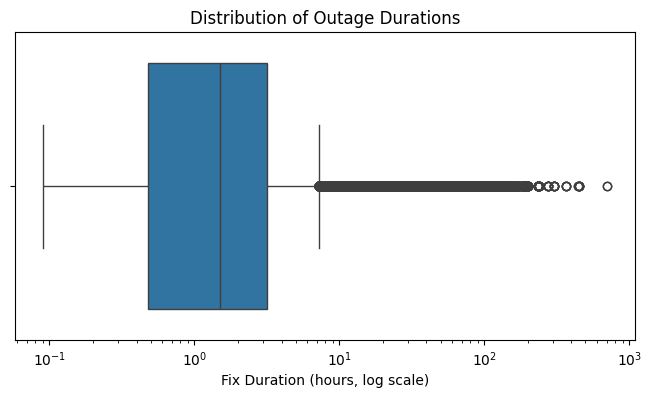

In [8]:
plt.figure(figsize=(8,4))
sns.boxplot(x=outage_events["fix_duration_hours"])
plt.xscale("log")   # recommended due to heavy tail
plt.xlabel("Fix Duration (hours, log scale)")
plt.title("Distribution of Outage Durations")
plt.show()

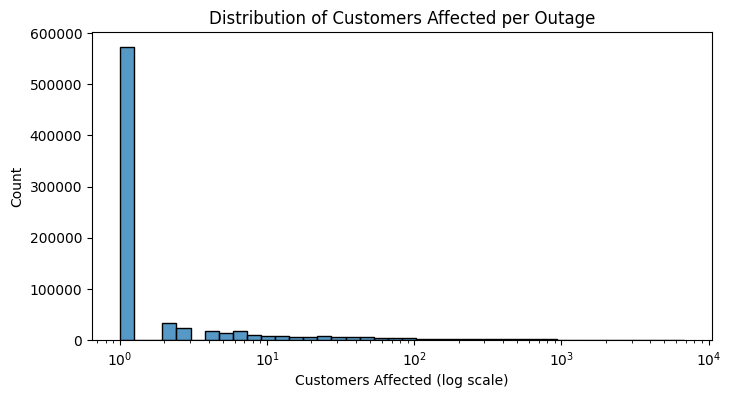

In [9]:
plt.figure(figsize=(8,4))
sns.histplot(outage_events["affected"], bins=40, log_scale=True)
plt.xlabel("Customers Affected (log scale)")
plt.title("Distribution of Customers Affected per Outage")
plt.show()

In [ ]:
# identify numeric columns automatically (excluding things like lon/lat if desired)
numeric_cols = outage_events.select_dtypes(include=[np.number]).columns.tolist()

#remove columns that don’t make sense as “extremes”
remove = ['device_lat',
          'device_lon',
          'TRACT',
          'outage_identifer', 
          'block_fips', 
          'convex_hull', 
          'jurisdiction',
          'origin',
          'state',
          'county',
          'cause',
          'outage_start_estimate',
          'outage_end_estimate',
          'outage_restored',
          'overlaps_helene',
          'month',
          'is_summer',
          'is_winter',
          'nearest_station',
          'start_date',
          'end_date',
          'outage_dates']

numeric_cols = [c for c in numeric_cols if c not in remove]

print("Using numeric columns:", numeric_cols)

# compute z-scores for each numeric column
zdf = outage_events.copy()
for col in numeric_cols:
    zdf[col + "_z"] = (outage_events[col] - outage_events[col].mean()) / outage_events[col].std(ddof=0)

# flag where |z| exceeds threshold (extreme)
threshold = 2
for col in numeric_cols:
    zdf[col + "_is_extreme"] = zdf[col + "_z"].abs() > threshold

# count extremes per TRACT
extreme_cols = [c for c in zdf.columns if c.endswith("_is_extreme")]
tract_extreme_counts = zdf.groupby("TRACT")[extreme_cols].sum()

# total across all cols
tract_extreme_counts["extreme_total"] = tract_extreme_counts.sum(axis=1)

# sort to get the tract with the most extreme values
top_extreme = tract_extreme_counts.sort_values("extreme_total", ascending=False)

print("Top TRACT with most extreme values:")
print(top_extreme.head(10))

top_extreme.to_csv("data_processed/outage_summary.csv", index= True)


Using numeric columns: ['affected', 'fix_duration_hours', 'customer_minutes_out']
Top TRACT with most extreme values:
        affected_is_extreme  fix_duration_hours_is_extreme  \
TRACT                                                        
950300                  168                           1098   
950400                  128                            840   
930100                   55                            610   
970200                  225                            288   
930400                   48                            486   
960102                  120                            402   
960302                  192                            246   
920300                  114                            372   
960301                  180                            270   
950200                   96                            336   

        customer_minutes_out_is_extreme  extreme_total  
TRACT                                                   
950300                 

In [20]:
# 1a) See how many geometries share each TRACT code
vc = gdf['TRACT'].value_counts()
print(vc[vc>1].head(10))   # show a few tract codes that repeat

# 1b) Inspect the full GEOID (if present) to confirm uniqueness
print("GEOID unique count:", gdf['GEOID'].nunique())
print("TRACT unique count:", gdf['TRACT'].nunique())
print("Total rows:", len(gdf))

# 1c) Show the rows for a sample repeated TRACT to see where they are
sample_tract = vc[vc>1].index[0]   # pick the first repeated TRACT
gdf[gdf['TRACT'] == sample_tract][['GEOID','TRACT']].head()

TRACT
970200    9
950101    8
970300    7
950102    7
930200    7
001000    7
001100    7
001200    7
970400    7
001500    6
Name: count, dtype: int64
GEOID unique count: 2623
TRACT unique count: 1759
Total rows: 2623


,GEOID,TRACT
87,37031970200,970200
117,37055970200,970200
526,37009970200,970200
717,37073970200,970200
874,37113970200,970200


Top 5 tracts:        TRACT  extreme_total  max_abs_z
1479  950300           1614  23.048542
1590  970200           1566  19.103730
1416  930100           1275  29.337835
1486  950400           1264  23.348390
1425  930400           1152  15.005471
Saved: top5_extreme_tracts.png


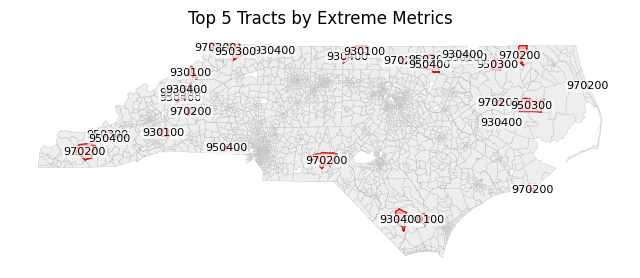

In [18]:
from pathlib import Path

gdf_path = Path("data_processed/socioeconomic_tracts_with_pca_and_clusters.geojson")
outages_path = Path("data_raw/outages.csv")   # change if your outages CSV is elsewhere

gdf = gpd.read_file(gdf_path)
gdf['TRACT'] = gdf.get('TRACT', gdf.get('GEOID', '')).astype(str).str.zfill(6)

df = outage_events
if 'TRACT' not in df.columns:
    if 'GEOID' in df.columns:
        df['TRACT'] = df['GEOID'].astype(str).str[-6:]
    elif 'tract' in df.columns:
        df['TRACT'] = df['tract']
df['TRACT'] = df['TRACT'].astype(str).str.zfill(6)

# choose numeric columns (exclude lat/lon/ids)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
exclude = ['device_lat','device_lon','lat','lon','longitude','latitude','TRACT','outage_identifier']
numeric_cols = [c for c in numeric_cols if c not in exclude]

# compute z-scores and flags
zdf = df.copy()
for c in numeric_cols:
    std = df[c].std(ddof=0)
    zdf[c + "_z"] = 0.0 if (std == 0 or pd.isna(std)) else (df[c] - df[c].mean()) / std
    zdf[c + "_is_extreme"] = zdf[c + "_z"].abs() > 2

extreme_flags = [c for c in zdf.columns if c.endswith("_is_extreme")]
tract_counts = zdf.groupby("TRACT")[extreme_flags].sum().astype(int)
tract_counts['extreme_total'] = tract_counts.sum(axis=1)
zcols = [c for c in zdf.columns if c.endswith("_z")]
tract_max_abs_z = zdf.assign(max_abs_z=zdf[zcols].abs().max(axis=1)).groupby("TRACT")['max_abs_z'].max()
tract_stats = tract_counts.merge(tract_max_abs_z, left_index=True, right_index=True)
tract_stats = tract_stats.reset_index().sort_values(['extreme_total','max_abs_z'], ascending=[False, False])
top5 = tract_stats.head(5)
print("Top 5 tracts:", top5[['TRACT','extreme_total','max_abs_z']])

# plot
plot_gdf = gdf.copy()
plot_gdf['is_top5'] = plot_gdf['TRACT'].isin(top5['TRACT'].astype(str).tolist())
top5_gdf = plot_gdf[plot_gdf['is_top5']].copy()

fig, ax = plt.subplots(1,1, figsize=(8,8))
plot_gdf.plot(ax=ax, color="#EEEEEE", edgecolor="#BBBBBB", linewidth=0.25)

if len(top5_gdf):
    top5_gdf.plot(
        ax=ax,
        facecolor='#ff9999',
        edgecolor='#cc0000',
        linewidth=0.9,
        alpha=0.9
    )

    # LABEL ONLY THE TRACT ID (no extreme score)
    for _, row in top5_gdf.iterrows():
        rep = row.geometry.representative_point()
        tract = row['TRACT']
        ax.text(
            rep.x,
            rep.y,
            tract,   # <-- only showing TRACT
            fontsize=8,
            ha='center',
            va='center',
            color='black',
            bbox=dict(boxstyle="round,pad=0.1", fc="white", ec="none", alpha=0.7)
        )

ax.set_axis_off()
plt.title("Top 5 Tracts by Extreme Metrics")
out_png = "top5_extreme_tracts.png"
plt.savefig(out_png, bbox_inches='tight', pad_inches=0.1)
print("Saved:", out_png)


In [21]:
# ensure df is your outage_events dataframe
df = outage_events.copy()

# If block_fips exists but is float-ish like 370670038032008.0 -> convert to string without .0
if 'block_fips' in df.columns:
    # convert to string robustly (handles floats and ints), drop decimal .0 if present
    df['block_fips_str'] = df['block_fips'].astype(str).str.replace(r'\.0+$', '', regex=True)
    # pad to 15 characters if needed (FIPS: 2+3+6+4 = 15)
    df['block_fips_str'] = df['block_fips_str'].str.zfill(15)
else:
    raise KeyError("block_fips column not found in outage_events")

# Optional: derive tract (6-digit) FROM the block_fips (positions 5:11 for 0-based index)
# This yields the 6-digit tract code embedded in the full FIPS
df['TRACT_from_block'] = df['block_fips_str'].str[5:11]  # 6 chars
df['TRACT_from_block'] = df['TRACT_from_block'].astype(str).str.zfill(6)

# sanity check
print("Example block_fips_str:", df['block_fips_str'].iloc[:3].tolist())
print("Derived TRACT_from_block:", df['TRACT_from_block'].iloc[:3].tolist())


Example block_fips_str: ['370670038032008', '371350121021009', '370630015011004']
Derived TRACT_from_block: ['003803', '012102', '001501']


In [22]:
import numpy as np
import pandas as pd

# pick numeric columns for z-scores (EXCLUDE identifiers)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
exclude = [
    'device_lat','device_lon','TRACT','outage_identifer','outage_identifier',
    'convex_hull','jurisdiction','origin','state','county','cause',
    'outage_start_estimate','outage_end_estimate','outage_restored',
    'overlaps_helene','month','is_summer','is_winter','nearest_station',
    'start_date','end_date','outage_dates','block_fips'  # exclude numeric block_fips column
]
numeric_cols = [c for c in numeric_cols if c not in exclude]
print("Numeric columns used for z-scores:", numeric_cols)

# compute z-scores and extreme flags on a copy
zdf = df.copy()
for col in numeric_cols:
    std = zdf[col].std(ddof=0)
    if std == 0 or pd.isna(std):
        zdf[col + "_z"] = 0.0
    else:
        zdf[col + "_z"] = (zdf[col] - zdf[col].mean()) / std
    zdf[col + "_is_extreme"] = zdf[col + "_z"].abs() > 2

# list of extreme flags
extreme_flags = [c for c in zdf.columns if c.endswith("_is_extreme")]

# --- AGGREGATE BY BLOCK (unique) ---
block_extreme_counts = zdf.groupby("block_fips_str")[extreme_flags].sum().astype(int)
block_extreme_counts["extreme_total"] = block_extreme_counts.sum(axis=1)
block_extreme_counts = block_extreme_counts.sort_values("extreme_total", ascending=False).reset_index()

print("Top 5 blocks with most extreme flags:")
print(block_extreme_counts.head(5)[["block_fips_str","extreme_total"]])

# --- ROLL-UP: aggregate block-level extremes to TRACT level (if you want tract summaries) ---
# we have df['TRACT_from_block'] derived earlier
# join block_extreme_counts (indexed by block_fips_str) back to a block->tract mapping (if needed)
block_to_tract = df[['block_fips_str','TRACT_from_block']].drop_duplicates().set_index('block_fips_str')
block_extreme_counts = block_extreme_counts.set_index('block_fips_str').join(block_to_tract, how='left')

# now aggregate by tract
tract_extreme_agg = block_extreme_counts.groupby('TRACT_from_block')[extreme_flags + ['extreme_total']].sum()
tract_extreme_agg = tract_extreme_agg.sort_values('extreme_total', ascending=False)
print("Top 5 tracts after aggregating block extremes:")
print(tract_extreme_agg.head(5)[['extreme_total']])


Numeric columns used for z-scores: ['affected', 'fix_duration_hours', 'customer_minutes_out']
Top 5 blocks with most extreme flags:
    block_fips_str  extreme_total
0  371910012001028            105
1  370899301001029            100
2  371219503001011             96
3  371219503001045             90
4  371219503002001             90
Top 5 tracts after aggregating block extremes:
                  extreme_total
TRACT_from_block               
950300                     1362
950400                     1036
930100                      725
970200                      639
930400                      582


Using outage_events from memory.
Loaded tracts GeoDataFrame with 2623 rows from data_processed/socioeconomic_tracts_with_pca_and_clusters.geojson
Numeric columns used for z-scores: ['affected', 'fix_duration_hours', 'customer_minutes_out', 'month']
Top 5 blocks with most extremes:
                 extreme_total TRACT_from_block
block_fips_str                                 
370119304003020            132           930400
370210031053012            128           003105
371139702002012            126           970200
370339303001037            120           930300
370899301003006            110           930100
Top 10 tracts by aggregated extreme_total:
    TRACT  extreme_total
0  950300           1614
1  970200           1566
2  930100           1275
3  950400           1264
4  930400           1152
5  950200           1116
6  960301            906
7  960302            888
8  960102            780
9  960502            768
Top tracts selected for mapping: ['950300', '970200', '930100', 

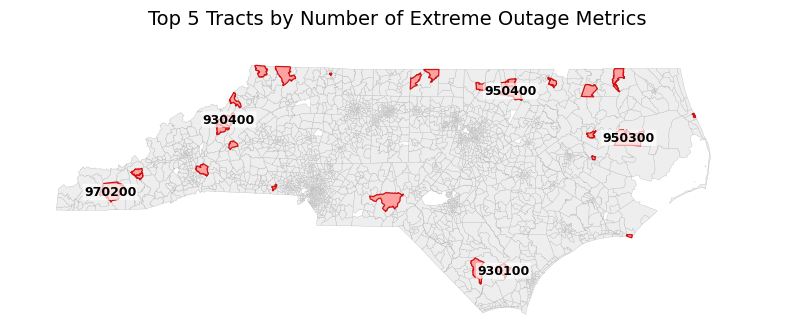

In [24]:
# ---- User-configurable paths & params ----
gdf_path = Path("data_processed/socioeconomic_tracts_with_pca_and_clusters.geojson")
#outages_csv = Path("data_raw/outages.csv")   # fallback if outage_events not in memory
output_png = "top_extreme_tracts_map.png"
TOP_N = 5   # number of top tracts to highlight
Z_THRESHOLD = 2.0

# ---- Load data (use outage_events if already defined in the session) ----
try:
    outage_events  # if this exists, use it
    df = outage_events.copy()
    print("Using outage_events from memory.")
except NameError:
    if outages_csv.exists():
        df = pd.read_csv(outages_csv)
        print(f"Loaded outages from {outages_csv}")
    else:
        raise RuntimeError("No outage_events in memory and outages CSV not found at: " + str(outages_csv))

# ---- Load tracts GeoDataFrame ----
gdf = gpd.read_file(gdf_path)
print(f"Loaded tracts GeoDataFrame with {len(gdf)} rows from {gdf_path}")

# Ensure gdf has a string TRACT column (6-digit) and preserve GEOID if present
if 'GEOID' in gdf.columns:
    gdf['GEOID'] = gdf['GEOID'].astype(str)
# create or normalize TRACT column (if present keep it, else derive from GEOID)
if 'TRACT' in gdf.columns:
    gdf['TRACT'] = gdf['TRACT'].astype(str).str.zfill(6)
else:
    if 'GEOID' in gdf.columns:
        gdf['TRACT'] = gdf['GEOID'].str[-6:].astype(str).str.zfill(6)
    else:
        raise RuntimeError("gdf has neither 'TRACT' nor 'GEOID' to derive tract id.")

# ---- Normalize/restore block_fips in outage df and derive tract ----
if 'block_fips' in df.columns:
    # robust string conversion: remove trailing .0 and pad to 15 (block FIPS length)
    df['block_fips_str'] = df['block_fips'].astype(str).str.replace(r'\.0+$', '', regex=True)
    # ensure numeric-like entries with scientific formatting are fixed by converting to integer where possible
    # but keep as string final
    df['block_fips_str'] = df['block_fips_str'].str.replace(r'\.0+$', '', regex=True)
    df['block_fips_str'] = df['block_fips_str'].str.zfill(15)
else:
    # if block_fips not available, try creating from state/county/tract fields if present
    if {'STATEFP','COUNTYFP','TRACT'}.issubset(df.columns):
        df['block_fips_str'] = (df['STATEFP'].astype(str).str.zfill(2) +
                                df['COUNTYFP'].astype(str).str.zfill(3) +
                                df['TRACT'].astype(str).str.zfill(6) +
                                df.get('BLOCK', '').astype(str).str.zfill(4))
    else:
        # proceed but warn: we still need a TRACT column for aggregation
        print("Warning: no block_fips present and cannot construct one. Proceeding with TRACT if present.")

# Derive a TRACT_from_block 6-digit code if possible
if 'block_fips_str' in df.columns:
    # block_fips_str expected: state(2)+county(3)+tract(6)+block(4) = 15 chars
    # tract substring = positions 2+3 -> 5..10 (0-indexed)
    # safer: take the middle 6 characters starting at position 5
    df['TRACT_from_block'] = df['block_fips_str'].str[5:11].astype(str).str.zfill(6)
else:
    # fallback: use existing TRACT or GEOID fields
    if 'TRACT' in df.columns:
        df['TRACT_from_block'] = df['TRACT'].astype(str).str.zfill(6)
    elif 'GEOID' in df.columns:
        df['TRACT_from_block'] = df['GEOID'].astype(str).str[-6:].str.zfill(6)
    else:
        raise RuntimeError("Cannot derive TRACT_from_block from outage data. Add block_fips or TRACT/GEOID columns.")

# Ensure TRACT_from_block exists
df['TRACT_from_block'] = df['TRACT_from_block'].astype(str).str.zfill(6)

# ---- Select numeric columns for z-scores (exclude identifiers) ----
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
exclude = [
    'device_lat','device_lon','lat','lon','longitude','latitude',
    'TRACT','GEOID','outage_identifier','outage_identifer',
    'block_fips'  # numeric orig col (we use block_fips_str instead)
]
numeric_cols = [c for c in numeric_cols if c not in exclude]
print("Numeric columns used for z-scores:", numeric_cols)

# If no numeric columns found, try to include float-like columns (coerce)
if len(numeric_cols) == 0:
    possible = [c for c in df.columns if df[c].dtype.kind in "fi"]
    numeric_cols = [c for c in possible if c not in exclude]
    print("Fallback numeric columns:", numeric_cols)

# ---- Compute z-scores and extreme flags ----
zdf = df.copy()
for col in numeric_cols:
    std = zdf[col].std(ddof=0)
    if std == 0 or pd.isna(std):
        zdf[col + "_z"] = 0.0
    else:
        zdf[col + "_z"] = (zdf[col] - zdf[col].mean()) / std
    zdf[col + "_is_extreme"] = zdf[col + "_z"].abs() > Z_THRESHOLD

extreme_flags = [c for c in zdf.columns if c.endswith("_is_extreme")]

# ---- Aggregate extremes at BLOCK level (unique blocks) ----
# group by block_fips_str if available, else group by TRACT_from_block (coarser)
if 'block_fips_str' in zdf.columns:
    block_group = zdf.groupby("block_fips_str")[extreme_flags].sum().astype(int)
    block_group['extreme_total'] = block_group.sum(axis=1)
    block_group = block_group.sort_values('extreme_total', ascending=False)
    # map block -> tract
    block_to_tract = zdf[['block_fips_str','TRACT_from_block']].drop_duplicates().set_index('block_fips_str')
    block_group = block_group.join(block_to_tract, how='left')
    print("Top 5 blocks with most extremes:")
    print(block_group.head(5)[['extreme_total','TRACT_from_block']])
else:
    # no block level, proceed to per-tract directly
    print("No block_fips_str found — skipping block-level aggregation")
    block_group = None

# ---- Aggregate to TRACT level (sum extremes across blocks in same tract) ----
# If block aggregation exists, use it; otherwise aggregate from row-level
if block_group is not None:
    tract_agg = block_group.reset_index().groupby('TRACT_from_block')[extreme_flags + ['extreme_total']].sum()
else:
    tract_agg = zdf.groupby('TRACT_from_block')[extreme_flags].sum().astype(int)
    tract_agg['extreme_total'] = tract_agg.sum(axis=1)

tract_agg = tract_agg.sort_values('extreme_total', ascending=False)
tract_agg = tract_agg.reset_index().rename(columns={'TRACT_from_block':'TRACT'})

print("Top 10 tracts by aggregated extreme_total:")
print(tract_agg.head(10)[['TRACT','extreme_total']])

# ---- Pick top N tracts ----
top_tracts = tract_agg.head(TOP_N)['TRACT'].astype(str).str.zfill(6).tolist()
print("Top tracts selected for mapping:", top_tracts)

# ---- Prepare tracts GeoDataFrame for plotting (dissolve so one geometry per 6-digit TRACT) ----
# If gdf contains multiple rows per 6-digit tract (across counties), dissolve to make unique
gdf_plot = gdf.copy()
# keep any attributes you want (take first value per TRACT)
attrs_to_keep = [c for c in ['GEOID','PC1','PC2','PC3','hc_cluster'] if c in gdf_plot.columns]
if len(attrs_to_keep):
    agg_dict = {c: 'first' for c in attrs_to_keep}
    unique_gdf = gdf_plot.dissolve(by='TRACT', aggfunc=agg_dict).reset_index()
else:
    unique_gdf = gdf_plot.dissolve(by='TRACT').reset_index()

# Mark the top tracts
unique_gdf['is_top'] = unique_gdf['TRACT'].isin(top_tracts)

# compute representative points for labeling
unique_gdf['label_pt'] = unique_gdf.geometry.representative_point()

# ---- Plot map ----
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
# base layer
unique_gdf.plot(ax=ax, color="#EEEEEE", edgecolor="#BBBBBB", linewidth=0.25)

# highlighted top tracts
if unique_gdf['is_top'].any():
    unique_gdf[unique_gdf['is_top']].plot(
        ax=ax,
        facecolor='#ff9999',
        edgecolor='#cc0000',
        linewidth=0.9,
        alpha=0.9
    )

    # add labels (one per tract)
    for _, row in unique_gdf[unique_gdf['is_top']].iterrows():
        pt = row['label_pt']
        tract_label = row['TRACT']
        ax.text(
            pt.x, pt.y, tract_label,
            fontsize=9, fontweight='bold',
            ha='center', va='center',
            color='black',
            bbox=dict(boxstyle="round,pad=0.12", fc="white", ec="none", alpha=0.7),
            zorder=6
        )

# tidy up
ax.set_axis_off()
ax.set_title(f"Top {TOP_N} Tracts by Number of Extreme Outage Metrics", fontsize=14)

# optionally set extent to area containing top tracts for a tighter zoom
if unique_gdf[unique_gdf['is_top']].geometry.notnull().any():
    bounds = unique_gdf[unique_gdf['is_top']].total_bounds  # xmin ymin xmax ymax
    xmin, ymin, xmax, ymax = bounds
    xpad = (xmax - xmin) * 0.15
    ypad = (ymax - ymin) * 0.15
    ax.set_xlim(xmin - xpad, xmax + xpad)
    ax.set_ylim(ymin - ypad, ymax + ypad)

plt.savefig(output_png, bbox_inches='tight', pad_inches=0.05, dpi=300)
print("Saved map to:", output_png)
plt.show()